In [1]:
import numpy as np
import time
import pandas as pd
from typing import Union
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math

In [2]:
from ambientfisher.interpolators import AmbientFisherInterpolator
from ambientfisher.interpolators import PoissonAFInterpolator
from ambientfisher.interpolators import GaussianProcessInterpolator

In [3]:
anchors_simulated_points_noOffAxis = [
                                        ((0.0, 0.0), 500.0), 
                                        ((1.0, 0.0), 506.0),  
                                        ((-1.0, 0.0), 499.), 
                                        ((0.0, 1.0), 550.0),   
                                        ((0.0, -1.0), 420.0), 
                                    ]

anchor_alphas = np.array([alpha_point[0] for alpha_point in anchors_simulated_points_noOffAxis])
anchor_nus = np.array([alpha_point[1] for alpha_point in anchors_simulated_points_noOffAxis])

n_obs = np.array([500.0])

In [4]:
def poisson_pmf(nu):
    def pmf(n_obs):
        logp = n_obs * np.log(nu) - nu - np.vectorize(math.lgamma)(n_obs + 1)
        return np.exp(logp)
    return pmf

anchor_pdfs = [poisson_pmf(nu_anchor) for nu_anchor in anchor_nus]
xarray = np.arange(0, 250, 1)

In [5]:
interp = AmbientFisherInterpolator(anchor_alphas, anchor_pdfs, xarray, plot_simplex=False)
interp_pois = PoissonAFInterpolator(anchor_alphas, anchor_nus, plot_simplex=False)
interp_gp = GaussianProcessInterpolator(anchor_alphas, anchor_nus / anchor_nus[0], length_scale=10.0, variance=1.0, noise=0.0)

In [6]:
import jax.numpy as jnp
import evermore as evm
from flax import nnx

@nnx.jit
def hf_like_from_cross_anchors(alpha):

    alpha = jnp.asarray(alpha)

    hist0 = jnp.array([anchor_nus[0]])

    up1   = jnp.array([anchor_nus[1]])  # (+1, 0)
    down1 = jnp.array([anchor_nus[2]])  # (-1, 0)

    up2   = jnp.array([anchor_nus[3]])  # (0, +1)
    down2 = jnp.array([anchor_nus[4]])  # (0, -1)

    p1 = evm.NormalParameter(value=alpha[0])
    p2 = evm.NormalParameter(value=alpha[1])

    m1 = p1.morphing(up_template=up1, down_template=down1)
    m2 = p2.morphing(up_template=up2, down_template=down2)

    # combine two independent systematics
    return (m1 @ m2)(hist0)


In [7]:
basis_ = anchor_alphas

HF_pred_nu_basis = np.zeros(len(anchor_alphas), dtype=float)
for k, a in enumerate(anchor_alphas):
    HF_pred_nu_basis[k] = float(hf_like_from_cross_anchors(a)[0])

In [16]:
num_scan_points = 100

param_1_range = np.linspace(-1.0, 1.0, num=num_scan_points)
param_2_range = np.linspace(-1.0, 1.0, num=num_scan_points)

X, Y = np.meshgrid(param_1_range, param_2_range, indexing="xy")

AF_pred_extrinsic = np.full_like(X, np.nan, dtype=float)
AF_pred_intrinsic = np.full_like(X, np.nan, dtype=float)
AF_pred_poisson = np.full_like(X, np.nan, dtype=float)
HF_pred = np.full_like(X, np.nan, dtype=float)
GP_pred = np.full_like(X, np.nan, dtype=float)

mask = np.zeros_like(X, dtype=bool)

for i in range(num_scan_points):
    for j in range(num_scan_points):
        alpha_target = np.array([X[j, i], Y[j, i]])
        try:
            pe = interp.predict_extrinsic(alpha_target, xobs=n_obs)
            pe = float(np.squeeze(pe))
            if np.isfinite(pe) and pe > 0:
                AF_pred_extrinsic[j, i] = (pe)
                mask[j, i] = True
        except Exception:
            pass
        try:
            pi = interp.predict_intrinsic(alpha_target, xobs=n_obs)
            AF_pred_intrinsic[j, i] = (pi)
        except Exception:
            pass
        try:
            nu = interp_pois.predict(alpha_target)
            AF_pred_poisson[j, i] = (poisson_pmf(nu)(n_obs).item())
        except Exception:
            pass

        nu_HF = hf_like_from_cross_anchors(alpha_target)
        HF_pred[j, i] = (poisson_pmf(nu_HF)(n_obs).item())

        nu_GP = interp_gp.predict(alpha_target, 
                               prior_mean_eval = nu_HF / anchor_nus[0], 
                               prior_mean_train = HF_pred_nu_basis / anchor_nus[0]) * anchor_nus[0]
        GP_pred[j, i] = (poisson_pmf(nu_GP)(n_obs).item())
        

In [9]:
# vmin = HF_pred.min()
# vmax = HF_pred.max()
# levels = np.linspace(vmin, vmax, 8)

# fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# im1 = axs[0][0].contourf(param_1_range, param_2_range, AF_pred_intrinsic)
# axs[0][0].axis('scaled')
# axs[0][0].set_title("Ambient Fisher prediction")
# axs[0][0].set_xlabel(r"$\alpha_1$")
# axs[0][0].set_ylabel(r"$\alpha_2$")
# fig.colorbar(im1, ax=axs[0][0])


# im2 = axs[0][1].contourf(param_1_range, param_2_range, AF_pred_poisson)
# axs[0][1].axis('scaled')
# axs[0][1].set_title("Poisson Ambient Fisher prediction")
# axs[0][1].set_xlabel(r"$\alpha_1$")
# axs[0][1].set_ylabel(r"$\alpha_2$")
# fig.colorbar(im2, ax=axs[0][1])

# im2 = axs[1][0].contourf(param_1_range, param_2_range, GP_pred)
# axs[1][0].axis('scaled')
# axs[1][0].set_title("Gaussian Process Regression (HF prior)")
# axs[1][0].set_xlabel(r"$\alpha_1$")
# axs[1][0].set_ylabel(r"$\alpha_2$")
# fig.colorbar(im2, ax=axs[1][0])

# im2 = axs[1][1].contourf(param_1_range, param_2_range, HF_pred)
# axs[1][1].axis('scaled')
# axs[1][1].set_title("HistFactory prediction")
# axs[1][1].set_xlabel(r"$\alpha_1$")
# axs[1][1].set_ylabel(r"$\alpha_2$")
# fig.colorbar(im2, ax=axs[1][1])

# xs = [0,  1, -1,  0,  0]
# ys = [0,  0,  0,  1, -1]

# for ax in axs.flat:
#     ax.plot(
#         xs, ys,
#         linestyle="None",
#         marker="x",
#         color="red",
#         markersize=8,
#         markeredgewidth=2
#     )

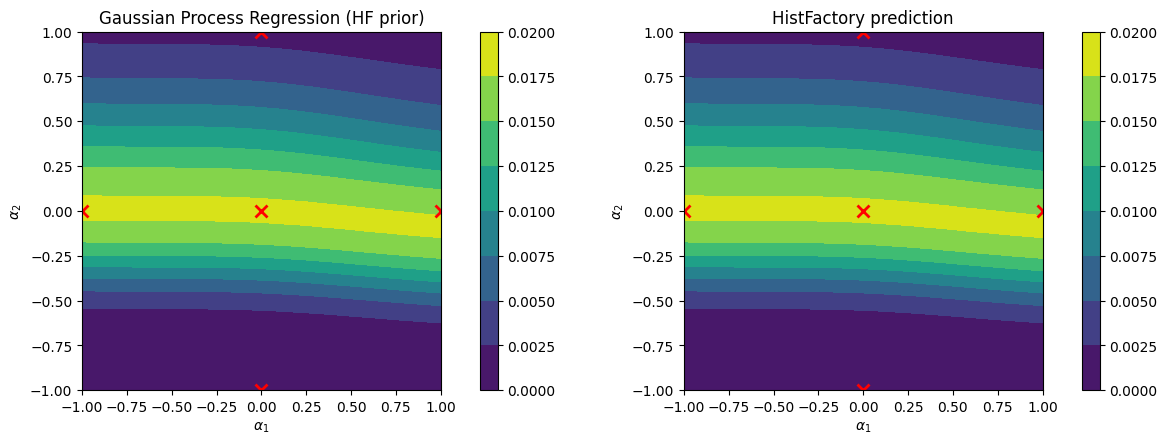

In [10]:
vmin = HF_pred.min()
vmax = HF_pred.max()
levels = np.linspace(vmin, vmax, 8)

fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# Hide top row
axs[0][0].set_visible(False)
axs[0][1].set_visible(False)

im1 = axs[1][0].contourf(param_1_range, param_2_range, GP_pred)
axs[1][0].axis('scaled')
axs[1][0].set_title("Gaussian Process Regression (HF prior)")
axs[1][0].set_xlabel(r"$\alpha_1$")
axs[1][0].set_ylabel(r"$\alpha_2$")
fig.colorbar(im1, ax=axs[1][0])

im2 = axs[1][1].contourf(param_1_range, param_2_range, HF_pred)
axs[1][1].axis('scaled')
axs[1][1].set_title("HistFactory prediction")
axs[1][1].set_xlabel(r"$\alpha_1$")
axs[1][1].set_ylabel(r"$\alpha_2$")
fig.colorbar(im2, ax=axs[1][1])

xs = [0,  1, -1,  0,  0]
ys = [0,  0,  0,  1, -1]

for ax in [axs[1][0], axs[1][1]]:
    ax.plot(
        xs, ys,
        linestyle="None",
        marker="x",
        color="red",
        markersize=8,
        markeredgewidth=2
    )

/tmp/ipykernel_2404986/2625689853.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  GP_pred_nu[i] = nu * anchor_nus[0]


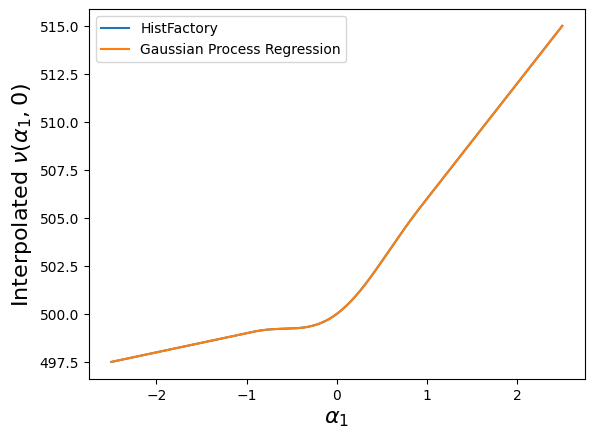

In [11]:
num_scan_points = 1000
param_1_range = np.linspace(-2.5, 2.5, num=num_scan_points)

HF_pred_nu = np.full_like(param_1_range, np.nan, dtype=float)
GP_pred_nu = np.full_like(param_1_range, np.nan, dtype=float)

mask = np.zeros_like(X, dtype=bool)

for i in range(num_scan_points):
    alpha_target = np.array([param_1_range[i], 0.0])

    nu = hf_like_from_cross_anchors(alpha_target)
    HF_pred_nu[i] = nu[0]

    nu = interp_gp.predict(alpha_target, 
                           prior_mean_eval = HF_pred_nu[i] / anchor_nus[0], 
                           prior_mean_train = HF_pred_nu_basis / anchor_nus[0]) 
    GP_pred_nu[i] = nu * anchor_nus[0]


plt.plot(param_1_range, HF_pred_nu, label='HistFactory')
plt.plot(param_1_range, GP_pred_nu, label='Gaussian Process Regression')
plt.xlabel(r"$\alpha_1$", size=16)
plt.ylabel(r"Interpolated $\nu (\alpha_1, 0)$", size=16)
# plt.plot(param_1_range, GP_pred_nu_der, label='Improved Gaussian Process Regression')

plt.legend()

/tmp/ipykernel_2404986/552864639.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  GP_pred_nu[i] = nu * anchor_nus[0]


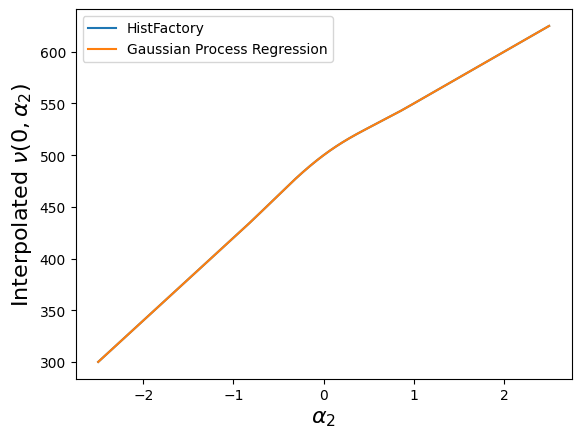

In [12]:
num_scan_points = 1000
param_2_range = np.linspace(-2.5, 2.5, num=num_scan_points)

HF_pred_nu = np.full_like(param_2_range, np.nan, dtype=float)
GP_pred_nu = np.full_like(param_2_range, np.nan, dtype=float)

mask = np.zeros_like(X, dtype=bool)

for i in range(num_scan_points):
    alpha_target = np.array([0.0, param_2_range[i]])

    nu = hf_like_from_cross_anchors(alpha_target)
    HF_pred_nu[i] = nu[0]

    nu = interp_gp.predict(alpha_target, 
                           prior_mean_eval = HF_pred_nu[i] / anchor_nus[0], 
                           prior_mean_train = HF_pred_nu_basis / anchor_nus[0]) 
    GP_pred_nu[i] = nu * anchor_nus[0]


plt.plot(param_2_range, HF_pred_nu, label='HistFactory')
plt.plot(param_2_range, GP_pred_nu, label='Gaussian Process Regression')
plt.xlabel(r"$\alpha_2$", size=16)
plt.ylabel(r"Interpolated $\nu (0, \alpha_2)$", size=16)
plt.legend()